In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pickle

Matplotlib is building the font cache; this may take a moment.


In [49]:
cols = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
df = pd.read_csv('magic04.data')
df.columns = cols

In [50]:
# Strip spaces and normalize column names
df.columns = df.columns.str.strip()

# Now select the features and target
X = df[['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist']]
y = df['class']




In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Convert target variable to numeric
y = label_encoder.fit_transform(df['class'])

# Now, split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [45]:
# Make predictions
y_pred = model.predict(X_test)

In [46]:
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.15450399158404812


In [51]:
# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [52]:
# Make predictions with Decision Tree
dt_y_pred = dt_model.predict(X_test)

In [53]:
# Evaluate Decision Tree using Accuracy
dt_accuracy = accuracy_score(y_test, dt_y_pred)
print(f'Decision Tree Accuracy: {dt_accuracy}')

Decision Tree Accuracy: 0.8172975814931651


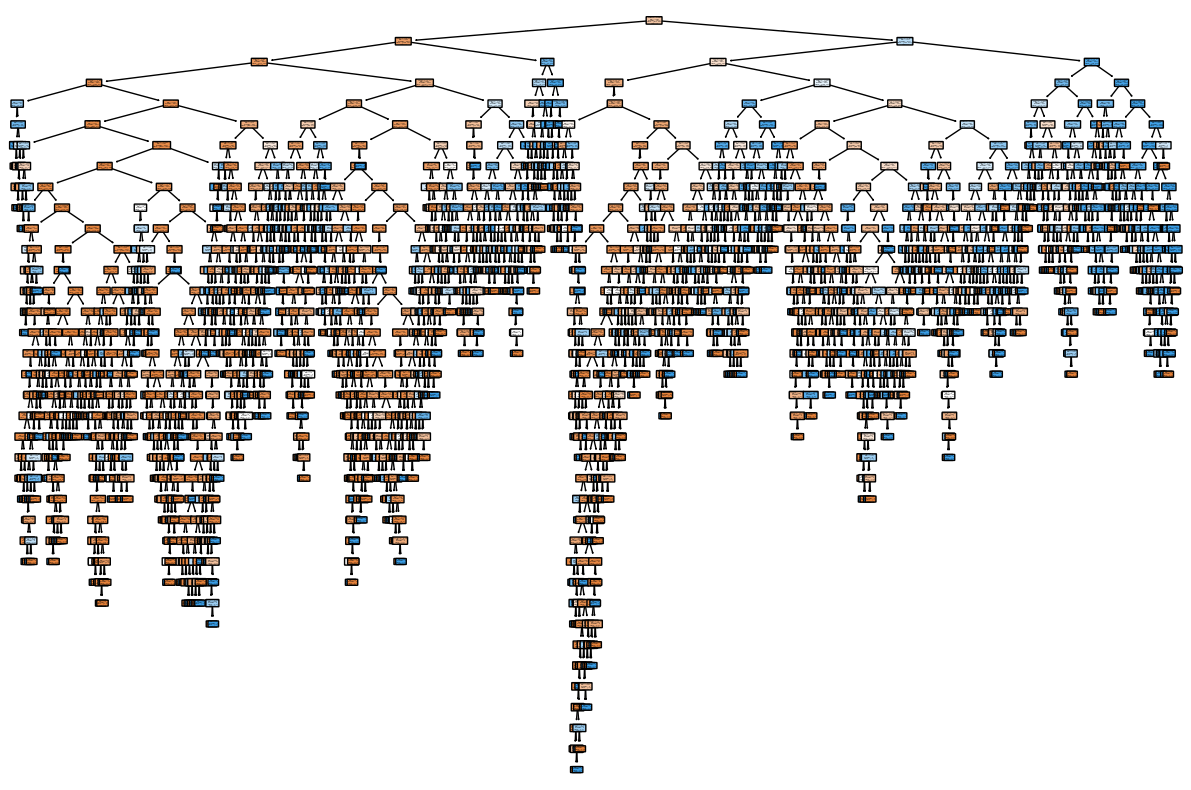

In [57]:
# Visualize the decision tree
plt.figure(figsize=(15, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=label_encoder.classes_, filled=True, rounded=True)
plt.show()

In [47]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [55]:
with open('dt_model.pkl', 'wb') as f:
    pickle.dump(dt_model, f)